In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import distance
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import numpy as np
import os
import geopandas as gpd
import pandas as pd
import datetime
from sklearn.cluster import DBSCAN
from pandas.plotting import table
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize, LinearSegmentedColormap

from matplotlib import gridspec
os.getcwd()

'/Users/artpark/Desktop/ka-maps'

In [2]:
# format yyyy-mm-dd
input_end_date = '2024-09-13'

end_date = pd.to_datetime(input_end_date)

# Provides previous 7th day (NOTE: while counting end_date is included) 
# start_date = (end_date - pd.Timedelta(days=6)).strftime('%Y-%m-%d')

start_date = pd.to_datetime(end_date - pd.Timedelta(days=13))

print(f"Start Date:",start_date)
print(f"End Date:",end_date)

save_file_path = './dengue_daily_reports_karnataka/bbmp_ward_level_hotspot/'
new_folder_name = f'bbmp-dengue-hotspots-{start_date.strftime('%b%d')}-{end_date.strftime('%b%d')}/'
save_dir = os.path.join(save_file_path, new_folder_name)
os.makedirs(save_dir, exist_ok=True)

type(start_date)

Start Date: 2024-08-31 00:00:00
End Date: 2024-09-13 00:00:00


pandas._libs.tslibs.timestamps.Timestamp

In [3]:

bbmp_data_file_path = './bbmp_data/bbmp_24to13.csv'

path_assembly_shape_files = './karnataka_shape_files_taluk_district/bbmp_assembly_boundary_SHP/AC_Boundary.shp'

In [4]:
#BBMP WARD WISE SHAPE FILE DATA

import geopandas as gpd
import matplotlib.pyplot as plt

# LOAD WARD WISE BBMP MAP
path_ward_shape_files = './karnataka_shape_files_taluk_district/BBMP/bbmp_final_new_wards-polygon.shp'

gdf_bbmp_ward = gpd.read_file(path_ward_shape_files)
gdf_bbmp_ward_wgs84 = gdf_bbmp_ward.to_crs(epsg=4326)

## Comment this if its not required tobe printed check the ward wise shape file 
# fig, ax_map = plt.subplots(figsize=(8, 4)) 
# gdf_bbmp_ward_wgs84.plot(ax=ax_map, color='white', edgecolor=(0.0, 0.8, 0.8), 
#                         alpha=0.5, linewidth=0.7)

gdf_bbmp_ward_wgs84['centroid'] = gdf_bbmp_ward_wgs84['geometry'].centroid
gdf_bbmp_ward_wgs84['centroid_longitude'] = gdf_bbmp_ward_wgs84['centroid'].x
gdf_bbmp_ward_wgs84['centroid_latitude'] = gdf_bbmp_ward_wgs84['centroid'].y

gdf_bbmp_ward_wgs84[['assembly_code', 'assembly_name']] = gdf_bbmp_ward_wgs84['assembly_1'].str.split('-', expand=True)
print(gdf_bbmp_ward_wgs84.columns)

gdf_bbmp_ward_wgs84[['ward_code', 'ward_name']] = gdf_bbmp_ward_wgs84['proposed_w'].str.split('-', expand=True)
print(len(gdf_bbmp_ward_wgs84['ward_name'].unique()))


# NAN check
columns_to_check = ['geometry','ward_code']
for column in columns_to_check:
    nan_check = gdf_bbmp_ward_wgs84[column].isna().any()
    print(f"Nan check for {column}")
    print(nan_check)
    print()


# DUPLICATE CHECK

duplicates_ward_code = gdf_bbmp_ward_wgs84[gdf_bbmp_ward_wgs84.duplicated(subset=['ward_code'])]
duplicates_ward_name = gdf_bbmp_ward_wgs84[gdf_bbmp_ward_wgs84.duplicated(subset=['ward_name'])]
duplicates_geometry = gdf_bbmp_ward_wgs84[gdf_bbmp_ward_wgs84.duplicated(subset=['geometry'])]

print('Duplicate rows based on ward_code:')
print(duplicates_ward_code)

print('Duplicate rows based on ward_name:')
print(duplicates_ward_name)

print('Duplicate rows based on geometry:')
print(duplicates_geometry)


print('Data types of columns:')
print(gdf_bbmp_ward_wgs84.dtypes)

# CHECK FOR DATA TYPES

gdf_bbmp_ward_wgs84['assembly_code'] = gdf_bbmp_ward_wgs84['assembly_code'].astype(str)
gdf_bbmp_ward_wgs84['ward_name'] = gdf_bbmp_ward_wgs84['ward_name'].astype(str)
gdf_bbmp_ward_wgs84[['ward_code','assembly_code']] = gdf_bbmp_ward_wgs84[['ward_code','assembly_code']]\
                                                .fillna(-1).astype(int)

print('Data types of columns:')
print(gdf_bbmp_ward_wgs84.dtypes)


Index(['id', 'proposed_w', 'proposed_1', 'ward_area', 'name_en', 'name_ka',
       'population', 'sc_populat', 'st_populat', 'male_popul', 'female_pop',
       'assembly_c', 'assembly_1', 'assembly_2', 'parliament', 'parliame_1',
       'parliame_2', 'bbox', 'geometry', 'centroid', 'centroid_longitude',
       'centroid_latitude', 'assembly_code', 'assembly_name'],
      dtype='object')
225
Nan check for geometry
False

Nan check for ward_code
False

Duplicate rows based on ward_code:
Empty GeoDataFrame
Columns: [id, proposed_w, proposed_1, ward_area, name_en, name_ka, population, sc_populat, st_populat, male_popul, female_pop, assembly_c, assembly_1, assembly_2, parliament, parliame_1, parliame_2, bbox, geometry, centroid, centroid_longitude, centroid_latitude, assembly_code, assembly_name, ward_code, ward_name]
Index: []

[0 rows x 26 columns]
Duplicate rows based on ward_name:
Empty GeoDataFrame
Columns: [id, proposed_w, proposed_1, ward_area, name_en, name_ka, population, sc_popula

/var/folders/0y/f_1604916677sp_j7gkzq8hc0000gn/T/ipykernel_8829/3094654145.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_bbmp_ward_wgs84['centroid'] = gdf_bbmp_ward_wgs84['geometry'].centroid


In [21]:
# LOAD ASSEMBLY WISE BBMP MAP

gdf_bbmp_assembly = gpd.read_file(path_assembly_shape_files)
gdf_bbmp_assembly_wgs84 = gdf_bbmp_assembly.to_crs(epsg=4326)

gdf_bbmp_assembly_wgs84= gdf_bbmp_assembly_wgs84.rename(columns={
                                                        'ASBLY_CSTN':'assembly_code',
                                                        'ASBLY_CS_1':'assembly_name'
                                                               })

# NAN check
columns_to_check = ['geometry','assembly_code','assembly_name']
for column in columns_to_check:
    nan_check = gdf_bbmp_assembly_wgs84[column].isna().any()
    print(f"Nan check for {column}")
    print(nan_check)
    print()

# DUPLICATE CHECK

duplicates_assembly_code = gdf_bbmp_assembly_wgs84[gdf_bbmp_assembly_wgs84.duplicated(subset=['assembly_name'])]
duplicates_assembly_name = gdf_bbmp_assembly_wgs84[gdf_bbmp_assembly_wgs84.duplicated(subset=['assembly_code'])]
duplicates_assembly_geometry = gdf_bbmp_assembly_wgs84[gdf_bbmp_assembly_wgs84.duplicated(subset=['geometry'])]

print('Duplicate rows based on ward_code:')
print(duplicates_assembly_code)

print('Duplicate rows based on ward_name:')
print(duplicates_assembly_name)

print('Duplicate rows based on geometry:')
print(duplicates_assembly_geometry)

print('Data types of columns:')
print(duplicates_assembly_code.dtypes)

Nan check for geometry
False

Nan check for assembly_code
False

Nan check for assembly_name
False

Duplicate rows based on ward_code:
Empty GeoDataFrame
Columns: [OBJECTID, assembly_code, assembly_name, PARLY_CSTN, KGISDistri, ASBLY_CS_2, SHAPE_Leng, SHAPE_Area, geometry]
Index: []
Duplicate rows based on ward_name:
Empty GeoDataFrame
Columns: [OBJECTID, assembly_code, assembly_name, PARLY_CSTN, KGISDistri, ASBLY_CS_2, SHAPE_Leng, SHAPE_Area, geometry]
Index: []
Duplicate rows based on geometry:
Empty GeoDataFrame
Columns: [OBJECTID, assembly_code, assembly_name, PARLY_CSTN, KGISDistri, ASBLY_CS_2, SHAPE_Leng, SHAPE_Area, geometry]
Index: []
Data types of columns:
OBJECTID            int64
assembly_code       int32
assembly_name      object
PARLY_CSTN          int32
KGISDistri         object
ASBLY_CS_2         object
SHAPE_Leng        float64
SHAPE_Area        float64
geometry         geometry
dtype: object


In [22]:
df_bbmp_raw = pd.read_csv(bbmp_data_file_path)

print(f"number of row entries:", len(df_bbmp_raw))
print(f"Column Names:", df_bbmp_raw.columns)

number of row entries: 718
Column Names: Index(['Case_Date', 'Patient_Name', 'mobile', 'gender', 'age', 'address',
       'Latitude', 'Longitude', 'test', 'date_of_reporting', 'reporting_lab',
       'Zone', 'ward', 'ward number ', 'Longitude\n', 'ZONE'],
      dtype='object')


In [23]:
select_columns = ['Patient_Name',	'mobile', 'gender','age','date_of_reporting','test','Latitude', 'Longitude', 'Zone', 'ward', 'ward number ']

In [24]:

df_bbmp_raw = df_bbmp_raw[select_columns].rename(columns={
                'date_of_reporting' : 'test_date',
                'test':'test_type',
                'Latitude' : 'latitude',
                'Longitude' : 'longitude',
                'Zone':'zone',
                'ward number ': 'ward_num_bbmp',
                'ward': 'ward_name_bbmp',
})

In [25]:
print(len(df_bbmp_raw))

718


In [26]:
df_bbmp_raw["test_date"]=pd.to_datetime(df_bbmp_raw['test_date'])

/var/folders/0y/f_1604916677sp_j7gkzq8hc0000gn/T/ipykernel_8829/299044173.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_bbmp_raw["test_date"]=pd.to_datetime(df_bbmp_raw['test_date'])


In [27]:
df_bbmp_raw = df_bbmp_raw.dropna(subset=['test_date'])

In [28]:

print(f"number of row entries:", len(df_bbmp_raw))
print(f" FILE Statrd_ Date:",df_bbmp_raw['test_date'].min())
print(f" FILE End_ Date:",df_bbmp_raw['test_date'].max())

number of row entries: 718
 FILE Statrd_ Date: 2024-01-09 00:00:00
 FILE End_ Date: 2024-12-09 00:00:00


In [29]:
# DATA LOAD , RENAME, FILTER

non_numeric_values = ['Out of BBMP', '', ' ']

# Fill missing values with empty strings and then perform the string operations
df_bbmp_raw['latitude'] = df_bbmp_raw['latitude'].fillna('').astype(str).str.replace(',', '').str.strip()
df_bbmp_raw['longitude'] = df_bbmp_raw['longitude'].fillna('').astype(str).str.replace(',', '').str.strip()

# Convert to numeric, coercing errors to NaN
df_bbmp_raw['latitude'] = pd.to_numeric(df_bbmp_raw['latitude'], errors='coerce')
df_bbmp_raw['longitude'] = pd.to_numeric(df_bbmp_raw['longitude'], errors='coerce')

# Drop rows with NaN values in latitude or longitude
df_bbmp_raw = df_bbmp_raw.dropna(subset=['latitude', 'longitude'])

df_bbmp_raw['test_date'] = pd.to_datetime(df_bbmp_raw['test_date'])

df_bbmp_last_7d = df_bbmp_raw[(df_bbmp_raw['test_date'] >= start_date) \
                         & (df_bbmp_raw['test_date'] <= end_date)].reset_index(drop=True)

print(f'hotspot start date:',start_date)
print(f'hotspot end date:',end_date)


hotspot start date: 2024-08-31 00:00:00
hotspot end date: 2024-09-13 00:00:00


In [30]:
df_bbmp_raw

,Patient_Name,mobile,gender,age,test_date,test_type,latitude,longitude,zone,ward_name_bbmp,ward_num_bbmp
0,AAINA HIBBA,9.686601e+09,Female,11 Years,2024-08-30,IgM ELISA,12.928950,77.603214,East,NaN,NaN
1,ABHIRAM,9.605510e+09,Male,26 Years,2024-08-30,NS1 Ag ELISA,29.076148,77.715263,Yelahanka,NaN,NaN
2,AFRA KHAN,7.676807e+09,Female,7 Years,2024-08-29,IgM ELISA,13.026681,77.629552,East,NaN,NaN
3,AFZAL QAYAM,9.334234e+09,Male,33 Years,2024-08-30,NS1 Ag ELISA,13.034936,77.599117,Yelahanka,NaN,NaN
4,ANJALI V,9.987000e+09,Female,45 Years,2024-08-29,IgM ELISA,12.795556,77.630797,Bommanahalli,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
89,SURENKUMAR,9.035349e+09,Male,14 Years,2024-08-28,NS1 Ag ELISA,13.011286,77.696361,Mahadevapura,NaN,NaN
90,SUSANTH SINNGH,8.130961e+09,Male,33 Years,2024-08-30,NS1 Ag ELISA,12.929233,77.576855,South,NaN,NaN
91,TANUSH,9.902117e+09,Male,6 Years,2024-08-31,NS1 Ag ELISA,12.971038,77.712624,Mahadevapura,NaN,NaN
92,Vedavathi,9.886600e+09,Female,37 Years,2024-08-30,NS1 Ag ELISA,13.015183,77.551292,west,NaN,NaN


In [31]:
# MAP BBMP LAT-LONG DATA TO SHAPE FILES

print(len(df_bbmp_last_7d))
df_bbmp_last_7d = df_bbmp_last_7d[(df_bbmp_last_7d['latitude'] >= -90) & (df_bbmp_last_7d['latitude'] <= 90)]
df_bbmp_last_7d = df_bbmp_last_7d[(df_bbmp_last_7d['longitude'] >= -180) & (df_bbmp_last_7d['longitude'] <= 180)]
df_bbmp_last_7d = df_bbmp_last_7d.reset_index(drop = True)

geometry = [Point(xy) for xy in zip(df_bbmp_last_7d['longitude'], df_bbmp_last_7d['latitude'])]

# Ensure there are no remaining problematic values
print(df_bbmp_raw['latitude'].head())
print(df_bbmp_raw['longitude'].head())

gdf_bbmp_last_7d = gpd.GeoDataFrame(df_bbmp_last_7d,crs='EPSG:4326', geometry=geometry)
gdf_bbmp_last_7d['centroid'] = gdf_bbmp_last_7d['geometry'].centroid
gdf_bbmp_last_7d['centroid_longitude_b'] = gdf_bbmp_last_7d['centroid'].x
gdf_bbmp_last_7d['centroid_latitude_b'] = gdf_bbmp_last_7d['centroid'].y

gdf_bbmp_last_7d['test_result'] = gdf_bbmp_last_7d['test_type'].apply(lambda x: 1 if x in ['NS1 Ag ELISA', 'IgM ELISA'] else 0)

print(len(df_bbmp_last_7d))
gdf_bbmp_last_7d

6
0    12.928950
1    29.076148
2    13.026681
3    13.034936
4    12.795556
Name: latitude, dtype: float64
0    77.603214
1    77.715263
2    77.629552
3    77.599117
4    77.630797
Name: longitude, dtype: float64
6


/var/folders/0y/f_1604916677sp_j7gkzq8hc0000gn/T/ipykernel_8829/2314128827.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_bbmp_last_7d['centroid'] = gdf_bbmp_last_7d['geometry'].centroid


,Patient_Name,mobile,gender,age,test_date,test_type,latitude,longitude,zone,ward_name_bbmp,ward_num_bbmp,geometry,centroid,centroid_longitude_b,centroid_latitude_b,test_result
0,DENCY WILSON,8.921390e+09,Female,31 Years,2024-08-31,NS1 Ag ELISA,12.293200,76.644444,East,NaN,NaN,POINT (76.64444 12.2932),POINT (76.64444 12.2932),76.644444,12.293200,1
1,Jaishankar H,9.880304e+09,Male,54 Years,2024-08-31,IgM ELISA,12.961867,77.677177,East,NaN,NaN,POINT (77.67718 12.96187),POINT (77.67718 12.96187),77.677177,12.961867,1
2,Shashwat Nawadia,7.829544e+09,Male,26 Years,2024-08-31,NS1 Ag ELISA,12.916669,77.675620,Mahadevapura,NaN,NaN,POINT (77.67562 12.91667),POINT (77.67562 12.91667),77.675620,12.916669,1
3,Vikas reddy S,9.980018e+09,Male,24 Years,2024-08-31,NS1 Ag ELISA,12.958705,77.667855,East,NaN,NaN,POINT (77.66786 12.95871),POINT (77.66786 12.95871),77.667855,12.958705,1
4,Yohan Yadav,8.586016e+09,Male,10 Years,2024-08-31,NS1 Ag ELISA,12.967106,77.641837,East,NaN,NaN,POINT (77.64184 12.96711),POINT (77.64184 12.96711),77.641837,12.967106,1
5,TANUSH,9.902117e+09,Male,6 Years,2024-08-31,NS1 Ag ELISA,12.971038,77.712624,Mahadevapura,NaN,NaN,POINT (77.71262 12.97104),POINT (77.71262 12.97104),77.712624,12.971038,1


In [32]:
# MERGE BBMP CASES WITH SHAPE FILES

# gdf_bbmp_last_7d = gdf_bbmp_last_7d.to_crs(epsg=32643)
# gdf_bbmp_last_7d.columns

gdf_cases_ward = gpd.sjoin(gdf_bbmp_last_7d, gdf_bbmp_ward_wgs84, how='left', predicate='within')

# # NAN check
columns_to_check = ['test_date','test_type','latitude', 'longitude',
                    'geometry','assembly_code','assembly_name','ward_code','ward_name']
nan_rows =[]
for column in columns_to_check:
    nan_check = gdf_cases_ward[column].isna().any()
    print(f"Nan check for {column}")
    print(nan_check)
    print()

nan_rows = gdf_cases_ward[gdf_cases_ward[columns_to_check].isna().any(axis=1)]
print(f'entires with NaN values:',len(nan_rows))

df_cases_ward = (gdf_cases_ward[~gdf_cases_ward[columns_to_check].isna().any(axis=1)]).reset_index(drop = True)
df_cases_ward[['ward_code','assembly_code']] = df_cases_ward[['ward_code','assembly_code']].astype(int)
df_cases_ward.dtypes

Nan check for test_date
False

Nan check for test_type
False

Nan check for latitude
False

Nan check for longitude
False

Nan check for geometry
False

Nan check for assembly_code
True

Nan check for assembly_name
True

Nan check for ward_code
True

Nan check for ward_name
True

entires with NaN values: 1


Patient_Name                    object
mobile                         float64
gender                          object
age                             object
test_date               datetime64[ns]
test_type                       object
latitude                       float64
longitude                      float64
zone                            object
ward_name_bbmp                 float64
ward_num_bbmp                  float64
geometry                      geometry
centroid_left                 geometry
centroid_longitude_b           float64
centroid_latitude_b            float64
test_result                      int64
index_right                    float64
id                             float64
proposed_w                      object
proposed_1                      object
ward_area                       object
name_en                         object
name_ka                         object
population                     float64
sc_populat                     float64
st_populat               

In [33]:
# PLOT CASES ON THE SHAPE FILES FOR INDIVIDUAL ZONES
# identify hotspots and wardname
from matplotlib import gridspec

def identify_hotspots(df_cases_ward):
    gdf = gpd.GeoDataFrame(df_cases_ward, 
                           geometry=gpd.points_from_xy(df_cases_ward['longitude'], 
                                                       df_cases_ward['latitude']))
    total_cases = len(df_cases_ward)
    
    gdf.set_crs(epsg=4326, inplace=True)
    gdf = gdf.to_crs(epsg=32643)  # Example for UTM zone 43N, adjust as necessary
    coords = np.array(list(gdf.geometry.apply(lambda geom: (geom.x, geom.y))))
    
    db = DBSCAN(eps=100, min_samples=1, metric='euclidean').fit(coords)
    gdf['cluster'] = db.labels_
    
    filtered_gdf = gdf[gdf['cluster'] != -1]
    valid_clusters = filtered_gdf.groupby('cluster').filter(lambda x: len(x) > 1)['cluster'].nunique()
    
    valid_cluster_labels = filtered_gdf.groupby('cluster').filter(lambda x: len(x) > 1)['cluster'].unique()
    highlighted_gdf = gdf[gdf['cluster'].isin(valid_cluster_labels)]
    
    return gdf, total_cases, valid_clusters, highlighted_gdf

In [34]:
assembly_codes = gdf_bbmp_assembly_wgs84['assembly_code'].unique()

NameError: name 'df_ward_summary' is not defined

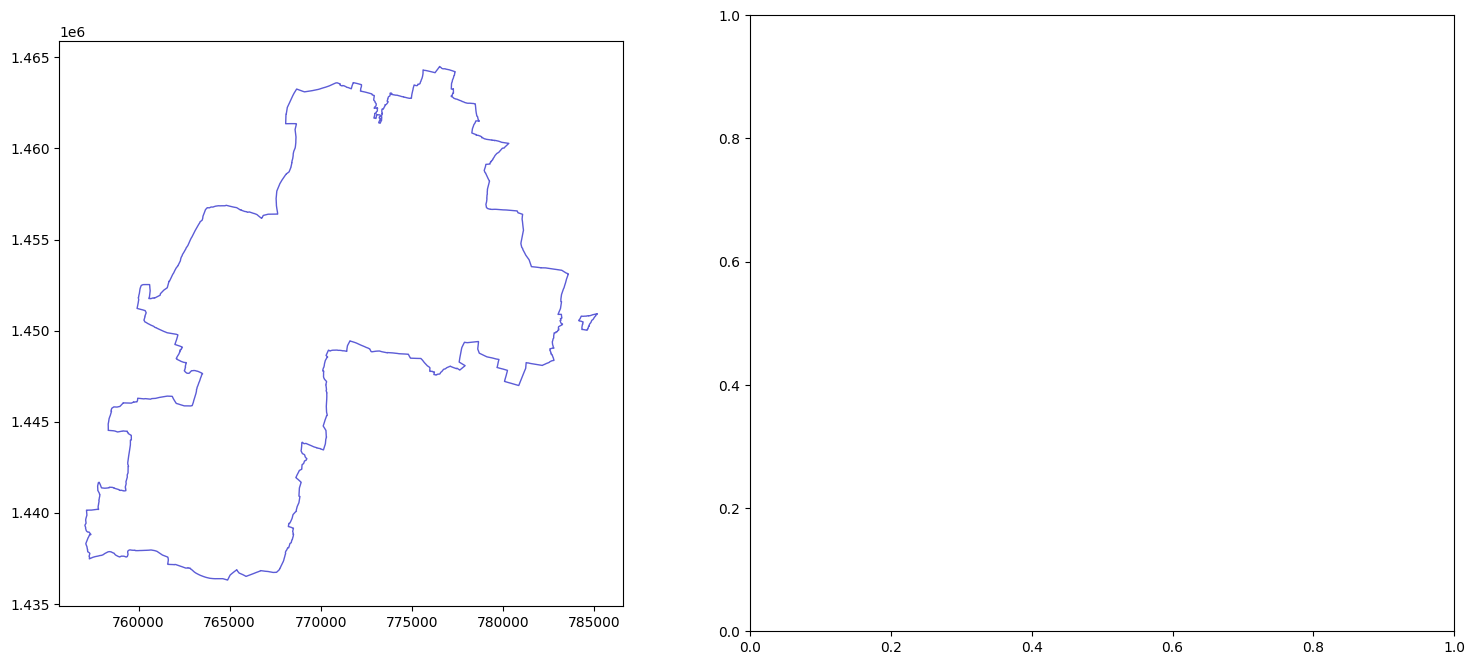

In [40]:
######################### ###### anuja Please copy starts #################################
######################### ###### anuja Please copy ends #################################

df_assembly_summary = pd.DataFrame()
for assembly_code in assembly_codes:
    df_cases_ward_filt = df_cases_ward[df_cases_ward['assembly_code']== assembly_code]
    gdf_bbmp_ward_wgs84_filt = gdf_bbmp_ward_wgs84[gdf_bbmp_ward_wgs84['assembly_code']==assembly_code]
    gdf_bbmp_assembly_wgs84_filt  = gdf_bbmp_assembly_wgs84[gdf_bbmp_assembly_wgs84['assembly_code']==assembly_code]
    df_cases_ward_filt_cases = df_cases_ward_filt.groupby(['ward_name', 'ward_code'])\
                                                      ['test_result'].sum().reset_index()
    ticks = []
    tick_labels = []
    ward_codes = df_cases_ward_filt_cases['ward_code'].unique()
    results = []
    # fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    fig = plt.figure(figsize=(18, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.25])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    gdf_bbmp_assembly_wgs84_filt = gdf_bbmp_assembly_wgs84_filt.to_crs(epsg=32643)
    gdf_bbmp_assembly_wgs84_filt.plot(ax=ax1, color='white', edgecolor=(0.2, 0.2, 0.8), 
                        alpha=0.8, linewidth=1)  
    
    for ward_code in ward_codes:
        df_cases_ward_sel = df_cases_ward_filt[df_cases_ward_filt['ward_code'] == ward_code]
        gdf_bbmp_ward_wgs84_sel = gdf_bbmp_ward_wgs84[gdf_bbmp_ward_wgs84['ward_code'] == ward_code]
        ward_name = gdf_bbmp_ward_wgs84_sel['ward_name'].values[0]
        assembly_name = gdf_bbmp_ward_wgs84_sel['assembly_name'].values[0]
        assembly_code = gdf_bbmp_ward_wgs84_sel['assembly_code'].values[0]
        # call function to identify hotspots
        gdf, total_cases_ward_sel, valid_clusters, highlighted_gdf = identify_hotspots(df_cases_ward_sel)
        results.append({
            'Assembly Code': assembly_code,
            'Assembly Name': assembly_name,
            'Ward Code': ward_code,
            'Ward Name': ward_name,
            'Total Cases': total_cases_ward_sel,
            'Number of Hotspots': valid_clusters
        })

        print(results)
        
        df_ward_summary = pd.DataFrame(results)

        if len(df_ward_summary)==0:
            continue
        
        gdf_bbmp_ward_wgs84_filt = gdf_bbmp_ward_wgs84_filt.to_crs(epsg=f'32643')
        df_ward_case_hotspot = pd.merge(df_ward_summary, gdf_bbmp_ward_wgs84_filt, 
        left_on=['Assembly Code', 'Assembly Name', 'Ward Code','Ward Name'], 
        right_on=['assembly_code', 'assembly_name', 'ward_code','ward_name'], 
        how='inner')
        gdf_bbmp_ward_wgs84_sel = gdf_bbmp_ward_wgs84_sel.to_crs(epsg=f'32643')
        gdf_bbmp_ward_wgs84_sel.plot(ax=ax1, color='white', edgecolor=(0.2, 0.4, 0.8), 
                                     alpha=0.8, linewidth=0.6)
        hotspot_color = (255/255, 0/255, 0/255)
        # ax.scatter(gdf.geometry.x, gdf.geometry.y, color=(255/255, 176/255, 66/255), alpha=0.8, marker='o', s=15, edgecolor='black', linewidth=0.3, label='Cases')
        ax1.scatter(highlighted_gdf.geometry.x, highlighted_gdf.geometry.y, 
                   color=hotspot_color, marker='o', alpha=1, s=30, edgecolor='black', 
                   linewidth=0.2, label='Hotspot(cases<100m)')
        for idx, row in gdf_bbmp_ward_wgs84_sel.iterrows():
            # Define the annotation parameters
            zone_name = row['ward_code']  # Replace 'ZoneName' with your actual column name
            x, y = row.geometry.centroid.x, row.geometry.centroid.y  # Centroid of the polygon
            # Add the annotation
            ax1.annotate(zone_name, xy=(x, y), xytext=(3, 3), 
                textcoords='offset points', fontsize=6, 
                color=(0.0, 0, 0.0, 1),ha='center')
        total_cases = df_ward_summary['Total Cases'].sum()
        total_hotspot = df_ward_summary['Number of Hotspots'].sum()
        # ax1.set_title(textstr, fontsize=12, loc='left')
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])
        ax1.tick_params(axis='both', which='both', length=0)
#%%%%%%%%%%%%%%% anuja Please insert this : copy starts %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#####################  4 indents get assembly level summary ##########################
    if len(df_ward_summary)==0:
        continue

    df_assembly_counts = df_ward_summary.groupby(['Assembly Name','Assembly Code'])\
                                            [['Total Cases','Number of Hotspots']].sum().reset_index()        
    df_assembly_summary = pd.concat([df_assembly_summary, df_assembly_counts], ignore_index=True)
#%%%%%%%%%%%%%%% anuja Please insert this : copy ends %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
################################## COLOR MAP DENGUE CASES##################################
    # gdf_bbmp_ward_wgs84_ward_filt = gdf_bbmp_ward_wgs84_ward_filt.to_crs(epsg=f'32643')
    gdf_bbmp_ward_wgs84_filt = gdf_bbmp_ward_wgs84_filt.to_crs(epsg=f'32643')
    # cases_min = df_ward_case_hotspot['Total Cases'].min()
    cases_min = 0
    cases_max = df_ward_case_hotspot['Total Cases'].max()
    norm = Normalize(vmin=cases_min, vmax=cases_max)
    colors = [
        (255/255, 245/255, 235/255, 0.6),  
        (254/255, 230/255, 206/255, 0.6),   
        (253/255, 208/255, 162/255, 0.6),   
        (253/255, 174/255, 107/255, 0.6), 
        (253/255, 141/255, 60/255, 0.6)
    ]
    if cases_max <=1:
        ticks = [0,1]
        cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=1)
    elif cases_max < 3 & cases_max > 1:
        ticks = [0, 1, 2]
        cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=2)
        tick_labels = [f'{int(t)}' for t in ticks]
    elif cases_max < 4 & cases_max > 3:
        ticks = [0, 1, 2, 3]
        cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=3)
        tick_labels = [f'{int(t)}' for t in ticks]
    elif cases_max < 5 & cases_max > 4 :
        ticks = [0, 1, 2, 3, 4]
        cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=4)
        tick_labels = [f'{int(t)}' for t in ticks]
    else:
        ticks = [cases_min + (i * (cases_max - cases_min) / 5) for i in range(6)]
        cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=5)
        tick_labels = [f'{int(t)}' for t in ticks]
    for idx, row in df_ward_case_hotspot.iterrows():
        cases = row['Total Cases']
        color = cmap(norm(cases))
        gdf_bbmp_ward_wgs84_filt.loc[
        gdf_bbmp_ward_wgs84_filt['ward_code'] == row['ward_code']].plot(
        ax=ax1, color=color, edgecolor=(0.5, 0.5, 0.5), 
        linewidth=0.4, alpha=0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1, orientation='vertical', shrink=1)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.set_title('cases', fontsize=14, pad=20)
    pos = ax1.get_position()
    left, bottom, width, height = pos.x0, pos.y0, pos.width, pos.height
    cbar.ax.set_position([left + width + 0.03, bottom, 0.02, height])  # [left, bottom, width, height]
################################### COLOR MAP DENGUE CASES ##################################
##################################### SUMMARY TABLE ####################################
    columns_to_keep = ['Ward Code', 'Ward Name',
       'Total Cases', 'Number of Hotspots']
    df_summary_filt = df_ward_summary[columns_to_keep]
    total_cases = df_summary_filt['Total Cases'].sum()
    total_hotspot = df_summary_filt['Number of Hotspots'].sum()
    df_summary_filt = df_summary_filt.rename(columns={
    'Ward Code': 'Ward \nCode',
    'Total Cases':'Total \nCases',
    'Number of Hotspots': 'Number of \nHotspots',
    })
    # Hide the axes
    ax2.xaxis.set_visible(False)
    ax2.yaxis.set_visible(False)
    ax2.set_frame_on(False)
    # Create a table
    table = ax2.table(cellText=df_summary_filt.values,
                     colLabels=df_summary_filt.columns,
                     cellLoc='center', loc='center')
    col_widths = [0.2, 0.38, 0.2, 0.2]  # Adjust these values based on your data
    for i, width in enumerate(col_widths):
        for j in range(len(df_summary_filt) + 1):  # +1 for the header
            cell = table[j, i]
            cell.set_width(width)
            if j == 0:
                cell.set_height(0.2)  # Adjust the header height as needed
            else:
                cell.set_height(0.075)  # Adjust the row height as needed
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1, 1)  # Adjust scaling as needed
    table_edge_color = (150/255, 150/255, 150/255,0.7) 
    cell_dict = table.get_celld()
    for (i, j), cell in cell_dict.items():
        cell.set_edgecolor(table_edge_color)
        cell.set_linewidth(0.3)  # Adjust this value to change line width
# Set Sans-Serif font family for all cells
    for key, cell in table.get_celld().items():
        cell.set_text_props(fontfamily='sans-serif')
    # ax2.set_title(title_str, fontsize=14,pad=0,loc='center')
    title_str = '\n'.join((f"Date: {start_date.strftime("%b %d")} to {end_date.strftime("%b %d")} (past 14 days)\n",
            f"Assembly Name: {assembly_name}\n",
            f"Total Cases: {total_cases}\n",
            f"Total Number of Hotspots: {total_hotspot} (Cases within 100m radius)\n",
            ))
    fig.suptitle(title_str,fontsize=14,fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])  # Adjust layout to make room for the main title
    save_hotspot_table = f'{save_dir}bbmp_{assembly_name}.png'
    plt.savefig(save_hotspot_table, dpi=300, bbox_inches='tight',pad_inches=0.5)
    plt.close(fig)
#%%%%%%%%%%%%%%% anuja Please insert this : copy starts %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
################### TABLE ASSEMBLY LEVEL SUMMARY #################################
df_assembly_summary_filt  = df_assembly_summary.copy()
columns_to_keep = ['Assembly Code','Assembly Name',
       'Total Cases', 'Number of Hotspots']
total_cases_assembly = df_assembly_summary_filt['Total Cases'].sum()
total_hotspot_assembly = df_assembly_summary_filt['Number of Hotspots'].sum()
df_assembly_summary_filt = df_assembly_summary_filt[columns_to_keep]\
                                .rename(columns={'Assembly Code':'Assembly \nCode',
                                                 'Assembly Name':'Assembly \nName',
                                                 'Total Cases':'Total \nCases',
                                                 'Number of Hotspots': 'Number of \nHotspots'
                                                })
df_assembly_summary_filt.drop_duplicates(inplace=True)
fig, ax3 = plt.subplots(figsize=(8, 10))
ax3.xaxis.set_visible(False)
ax3.yaxis.set_visible(False)
ax3.set_frame_on(False)
# Create a table
table = ax3.table(cellText=df_assembly_summary_filt.values,
                     colLabels=df_assembly_summary_filt.columns,
                     cellLoc='center', loc='center')
col_widths = [0.2, 0.45, 0.2, 0.2]  # Adjust these values based on your data
for i, width in enumerate(col_widths):
    for j in range(len(df_assembly_summary_filt) + 1):  # +1 for the header
        cell = table[j, i]
        cell.set_width(width)
        if j == 0:
            cell.set_height(0.1)  # Adjust the header height as needed
        else:
            cell.set_height(0.06)  # Adjust the row height as needed
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.25)  # Adjust scaling as needed
table_edge_color = (150/255, 150/255, 150/255,0.7) 
cell_dict = table.get_celld()
for (i, j), cell in cell_dict.items():
    cell.set_edgecolor(table_edge_color)
    cell.set_linewidth(0.3)  # Adjust this value to change line width
# Set Sans-Serif font family for all cells
for key, cell in table.get_celld().items():
    cell.set_text_props(fontfamily='sans-serif')
title_str = f"Date: {start_date.strftime("%b %d")} to {end_date.strftime("%b %d")} (past 14 days)"
            # f"BBMP Total Cases: {total_cases_assembly}",
            # f"BBMP Total Number of Hotspots: {total_hotspot_assembly}",
            # f""
plt.title(title_str,fontsize=14,fontweight='bold',y=1.8)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])  # Adjust layout to make room for the main title
save_hotspot_table = f'{save_dir}bbmp_assembly_summary_cases_hotspot.png'
plt.savefig(save_hotspot_table, dpi=300, bbox_inches='tight',pad_inches=0.5)
plt.close(fig)
############################# TABLE ENDS ###########################################
#%%%%%%%%%%%%%%% anuja Please insert this : copy ends %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [38]:
df_cases_ward.to_csv("cases_by_hotspot.csv", index=False)